Fetching Wikipedia data...
 -> Inflation
 -> Recession
 -> War
 -> Donald_Trump
 -> Pandemic
 -> Unemployment
 -> Anxiety


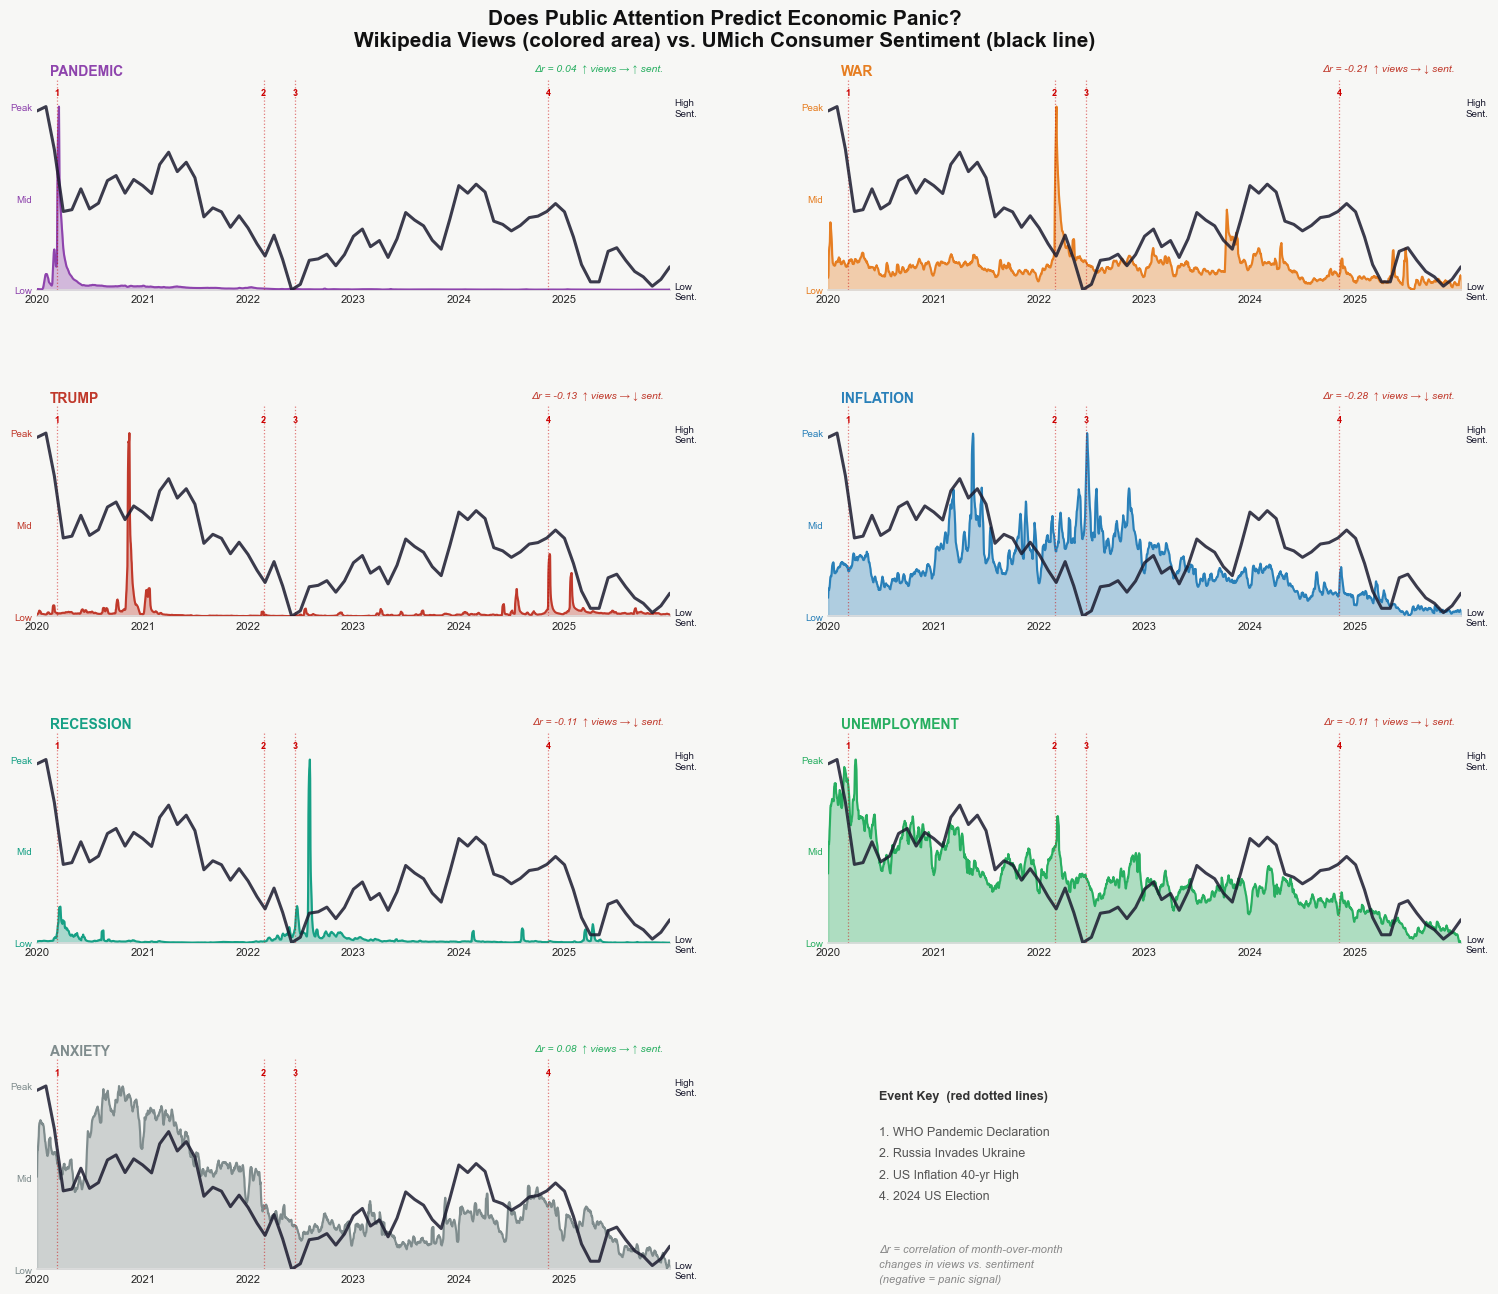

Saved: DataMiningFinalFigure.png


In [15]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time

# Fetch Wikipedia data
def get_pageviews(article, start="20200101", end="20260101"):
    headers = {'User-Agent': 'ResearchProjectBot/1.0'}
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"en.wikipedia/all-access/user/{article}/daily/{start}/{end}"
    )
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            if 'items' in data:
                df = pd.DataFrame(data['items'])
                df['date'] = pd.to_datetime(df['timestamp'], format='%Y%m%d%H')
                df['views'] = pd.to_numeric(df['views'])
                df['article_raw'] = article
                return df[['date', 'views', 'article_raw']]
    except Exception as e:
        print(f"Error fetching {article}: {e}")
    return pd.DataFrame()

articles = ["Inflation", "Recession", "War", "Donald_Trump",
            "Pandemic", "Unemployment", "Anxiety"]

all_dfs = []
print("Fetching Wikipedia data...")
for art in articles:
    print(f" -> {art}")
    df = get_pageviews(art)
    if not df.empty:
        all_dfs.append(df)
    time.sleep(0.1)

wiki_data = pd.concat(all_dfs, ignore_index=True)
wiki_data = wiki_data.sort_values(["article_raw", "date"])

# 7-day rolling average
wiki_data["smoothed"] = (
    wiki_data.groupby("article_raw")["views"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Normalize each topic 0–1 independently
wiki_data["norm"] = wiki_data.groupby("article_raw")["smoothed"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

name_map = {
    "Donald_Trump":  "Trump",
    "Inflation":     "Inflation",
    "Recession":     "Recession",
    "Unemployment":  "Unemployment",
    "War":           "War",
    "Pandemic":      "Pandemic",
    "Anxiety":       "Anxiety",
}
wiki_data["label"] = wiki_data["article_raw"].map(name_map)

# Load and normalize sentiment
sentiment_df = pd.read_csv("UMCSENT.csv")
sentiment_df["date"] = pd.to_datetime(sentiment_df["observation_date"])
s_min, s_max = sentiment_df["UMCSENT"].min(), sentiment_df["UMCSENT"].max()
sentiment_df["norm"] = (sentiment_df["UMCSENT"] - s_min) / (s_max - s_min)
# Not inverted: high sentiment = high on chart (confident), low = low (panicked)

# Layout
topic_order = ["Pandemic", "War", "Trump", "Inflation",
               "Recession", "Unemployment", "Anxiety"]

topic_colors = {
    "Pandemic":     "#8E44AD",
    "War":          "#E67E22",
    "Trump":        "#C0392B",
    "Inflation":    "#2980B9",
    "Recession":    "#16A085",
    "Unemployment": "#27AE60",
    "Anxiety":      "#7F8C8D",
}

SENTIMENT_COLOR = "#1A1A2E"
BG = "#F7F7F5"

fig = plt.figure(figsize=(16, 14), facecolor=BG)
fig.suptitle(
    "Does Public Attention Predict Economic Panic?\n"
    "Wikipedia Views (colored area) vs. UMich Consumer Sentiment (black line)",
    fontsize=15, fontweight="bold", color="#111111", y=0.98
)

# 4 rows × 2 cols for 7 topics
gs = gridspec.GridSpec(
    4, 2,
    figure=fig,
    hspace=0.55,
    wspace=0.25,
    left=0.07, right=0.96,
    top=0.93, bottom=0.08
)

positions = [
    (0, 0), (0, 1),
    (1, 0), (1, 1),
    (2, 0), (2, 1),
    (3, 0),
]

events = {
    "2020-03-11": "1. WHO Pandemic Declaration",
    "2022-02-24": "2. Russia Invades Ukraine",
    "2022-06-13": "2. US Inflation 40-yr High",
    "2024-11-05": "4. 2024 US Election",
}
event_dates = list(events.keys())
event_labels = list(events.values())

# Compute monthly Δ sentiment for correlation
# Resample sentiment to monthly, then take month-over-month change
sent_monthly = (
    sentiment_df.set_index("date")["UMCSENT"]
    .resample("MS").mean()
    .diff()
    .dropna()
    .rename("delta_sent")
    .reset_index()
)

axes = []
for idx, (topic, (row, col)) in enumerate(zip(topic_order, positions)):
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor(BG)
    axes.append(ax)

    color = topic_colors[topic]
    sub = wiki_data[wiki_data["label"] == topic].sort_values("date")

    # Wiki area (left y-axis)
    ax.fill_between(sub["date"], 0, sub["norm"],
                    color=color, alpha=0.35, zorder=2)
    ax.plot(sub["date"], sub["norm"],
            color=color, linewidth=1.5, zorder=3)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["Low", "Mid", "Peak"], fontsize=7, color=color)
    ax.tick_params(axis='y', colors=color, length=0)

    # Sentiment line (right y-axis)
    ax2 = ax.twinx()
    ax2.plot(sentiment_df["date"], sentiment_df["norm"],
             color=SENTIMENT_COLOR, linewidth=2.2, linestyle="-",
             zorder=4, alpha=0.85)
    ax2.set_ylim(0, 1.15)
    ax2.set_yticks([0, 0.5, 1])
    ax2.set_yticklabels(["Low\nSent.", "", "High\nSent."],
                        fontsize=7, color=SENTIMENT_COLOR)
    ax2.tick_params(axis='y', colors=SENTIMENT_COLOR, length=0)
    ax2.set_facecolor(BG)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    # Event lines (numbered)
    for i, (date_str, _) in enumerate(events.items(), 1):
        xv = pd.to_datetime(date_str)
        ax.axvline(xv, color="#CC0000", linewidth=0.9,
                   linestyle=":", alpha=0.5, zorder=5)
        ax.text(xv, 1.10, str(i), fontsize=6.5, color="#CC0000",
                ha="center", va="top", fontweight="bold", zorder=6)

    # X-axis: show only year labels
    ax.set_xlim(sub["date"].min(), sub["date"].max())
    years = pd.date_range("2020", "2025", freq="YS")
    ax.set_xticks(years)
    ax.set_xticklabels([str(y.year) for y in years], fontsize=8)
    ax.tick_params(axis='x', length=0)

    # Spines
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#DDDDDD")

    # Title badge
    ax.text(0.02, 1.07, topic.upper(), transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=color, va="top")

    # Pearson r on month-over-month changes
    # Resample wiki views to monthly mean, then diff
    wiki_monthly = (
        sub.set_index("date")["smoothed"]
        .resample("MS").mean()
        .diff()
        .dropna()
        .rename("delta_wiki")
        .reset_index()
    )
    merged = pd.merge_asof(
        wiki_monthly.sort_values("date"),
        sent_monthly.sort_values("date"),
        on="date", direction="nearest"
    ).dropna()

    r = merged["delta_wiki"].corr(merged["delta_sent"])
    direction = "↑ views → ↑ sent." if r > 0 else "↑ views → ↓ sent."
    r_color = "#27AE60" if r > 0 else "#C0392B"
    ax.text(0.99, 1.07, f"Δr = {r:.2f}  {direction}",
            transform=ax.transAxes, fontsize=7.5,
            color=r_color, va="top", ha="right", fontstyle="italic")

# Event legend in bottom-right cell
ax_leg = fig.add_subplot(gs[3, 1])
ax_leg.set_facecolor(BG)
ax_leg.axis("off")

legend_lines = "\n".join(event_labels)
ax_leg.text(0.08, 0.85,
            "Event Key  (red dotted lines)",
            transform=ax_leg.transAxes,
            fontsize=9, fontweight="bold", color="#333333", va="top")
ax_leg.text(0.08, 0.68,
            legend_lines,
            transform=ax_leg.transAxes,
            fontsize=9, color="#555555", va="top", linespacing=2.0)
ax_leg.text(0.08, 0.12,
            "Δr = correlation of month-over-month\nchanges in views vs. sentiment\n"
            "(negative = panic signal)",
            transform=ax_leg.transAxes,
            fontsize=8, color="#888888", va="top", linespacing=1.6,
            fontstyle="italic")



plt.savefig("DataMiningFinalFigure.png",
            dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: DataMiningFinalFigure.png")